In [1]:
import numpy as np
import random
import networkx as nx




random.seed(101)

In [2]:
def generate_dsbm(N, M, min_rate, max_rate, alpha_range, beta_range):
    # Step 1: Generate block sizes randomly between 0.01% and 0.9% of N
    min_block_size = int(min_rate * N)
    max_block_size = int(max_rate * N)
    
    # Random block sizes
    block_sizes = np.random.randint(min_block_size, max_block_size, size=M)
    # Normalize block sizes to ensure their sum equals N
    block_sizes = (block_sizes / block_sizes.sum() * N).astype(int)
    # Adjust any discrepancy caused by rounding errors
    difference = N - block_sizes.sum()
    block_sizes[0] += difference
    
    edge_list = []
    block_assignment = {}
    
    # Step 2: Assign blocks to nodes and keep track of block indices
    block_indices = []
    start_idx = 0
    for block_id, size in enumerate(block_sizes):
        block_indices.append(list(range(start_idx, start_idx + size))) 
        # a list of lists, each list contains the node id in this block
        for node in range(start_idx, start_idx + size):
            block_assignment[node] = block_id  # Assign the node to the block
        start_idx += size
    
    # Step 3: Fill the edge list using matrix-based operations
    for i in range(M):
        # Intra-block edges with probability alpha
        alpha = random.uniform(*alpha_range)
        block_size = len(block_indices[i])
        
        # Generate a random adjacency matrix for the block
        rand_matrix = np.random.rand(block_size, block_size)
        intra_edges = (rand_matrix < alpha).astype(int)
        
        # Remove self-loops
        np.fill_diagonal(intra_edges, 0)
        
        # Add edges to the edge_list
        u_nodes = block_indices[i]
        for u_idx, u in enumerate(u_nodes):
            for v_idx, v in enumerate(u_nodes):
                if intra_edges[u_idx, v_idx]:
                    edge_list.append((u, v))
        
        # Inter-block edges with probability beta
        for j in range(i + 1, M):
            beta = random.uniform(*beta_range)
            inter_size_i = len(block_indices[i])
            inter_size_j = len(block_indices[j])
            
            # Generate a random adjacency matrix between blocks i and j
            rand_matrix_inter = np.random.rand(inter_size_i, inter_size_j)
            inter_edges = (rand_matrix_inter < beta).astype(int)
            
            # Add edges between blocks i and j
            for u_idx, u in enumerate(block_indices[i]):
                for v_idx, v in enumerate(block_indices[j]):
                    if inter_edges[u_idx, v_idx]:
                        edge_list.append((u, v))
                    if np.random.rand() < beta:  # Check for reverse edge
                        edge_list.append((v, u))
    
    return edge_list, block_assignment

In [3]:
def adjust_edges(edge_list, block_assignment, N, X, Y):
    # Step 1: Initialize the adjacency list to track out-edges for each node
    out_edges = {v: [] for v in range(N)}
    for u, v in edge_list:
        out_edges[u].append(v)
    
    # Step 2: Iterate over each node
    for v in range(N):
        # Step 3: Pick random values x and y (desired out-edges)
        x = random.randint(0, X)
        y = random.randint(0, Y)
        
        # Step 4: Count current inter-block (i) and intra-block (j) out-edges
        intra_neighbors = [neighbor for neighbor in out_edges[v] if block_assignment[neighbor] == block_assignment[v]]
        inter_neighbors = [neighbor for neighbor in out_edges[v] if block_assignment[neighbor] != block_assignment[v]]
        i = len(intra_neighbors)
        j = len(inter_neighbors)
        
        # Step 5: Adjust intra-block edges if i < x
        while i < x:
            if i == 0:
                break
            # Pick a random neighbor from the same block
            neighbor = random.choice(intra_neighbors)
            edge_list.append((v, neighbor))
            out_edges[v].append(neighbor)
            i += 1
        
        # Step 6: Adjust inter-block edges if j < y
        while j < y:
            if j==0:
                break
            neighbor = random.choice(inter_neighbors)     
            edge_list.append((v, neighbor))
            out_edges[v].append(neighbor)
            j += 1
    
    return edge_list

In [8]:
# Example usage
N = 50000   # Total number of nodes
M = 5000      # Number of blocks (modules)
alpha = (0.0003,0.005)  # Intra-block connection probability
beta = (0.0001,0.0002)   # Inter-block connection probability
X = 6  # Maximum intra-block edges for each node
Y = 3   # Maximum inter-block edges for each node

# Generate initial DSBM network
edge_list, block_assignment = generate_dsbm(N, M, 0.0001,0.009,alpha, beta)


In [9]:
edge_list

[(0, 109),
 (0, 573),
 (0, 1163),
 (0, 1323),
 (0, 1404),
 (0, 1617),
 (0, 1738),
 (0, 2289),
 (1, 7),
 (1, 121),
 (1, 1004),
 (1, 1044),
 (1, 1072),
 (1, 1077),
 (1, 1110),
 (1, 1354),
 (1, 2046),
 (2, 649),
 (2, 1177),
 (2, 1893),
 (2, 2071),
 (2, 2097),
 (2, 2326),
 (2, 2444),
 (2, 2498),
 (3, 395),
 (3, 424),
 (3, 951),
 (3, 1201),
 (3, 1482),
 (3, 1998),
 (4, 198),
 (4, 436),
 (4, 738),
 (4, 953),
 (4, 1110),
 (4, 1132),
 (4, 1174),
 (4, 1327),
 (4, 1444),
 (4, 1536),
 (4, 1843),
 (5, 693),
 (5, 879),
 (5, 1029),
 (5, 1139),
 (5, 1354),
 (5, 1626),
 (6, 98),
 (6, 248),
 (6, 318),
 (6, 714),
 (6, 824),
 (6, 1570),
 (6, 1915),
 (6, 2258),
 (6, 2323),
 (7, 97),
 (7, 268),
 (7, 573),
 (7, 586),
 (7, 587),
 (7, 600),
 (7, 997),
 (7, 1040),
 (7, 1181),
 (7, 1199),
 (7, 1201),
 (7, 1266),
 (7, 1329),
 (7, 1574),
 (7, 1644),
 (7, 1923),
 (7, 2008),
 (8, 382),
 (8, 450),
 (8, 1434),
 (8, 1445),
 (8, 1671),
 (8, 1778),
 (8, 2187),
 (8, 2214),
 (9, 64),
 (9, 271),
 (9, 345),
 (9, 502),
 (9, 

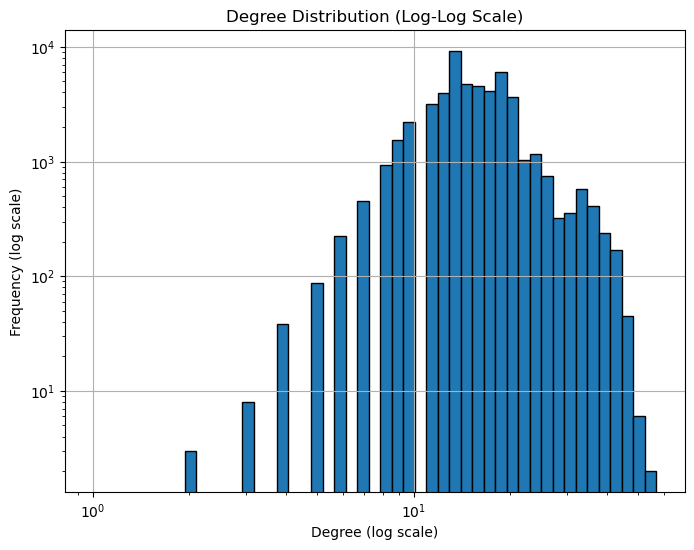

In [11]:
from collections import Counter 
import matplotlib.pyplot as plt
degree_count = Counter()
for u, v in edge_list:
    degree_count[u] += 1
    degree_count[v] += 1  # Increase degree for both ends of the edge

# Extract the degree values
degrees = np.array(list(degree_count.values()))

# Step 3: Plot the degree distribution
plt.figure(figsize=(8, 6))
plt.hist(degrees, bins=np.logspace(np.log10(1), np.log10(max(degrees)), 50), edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Degree (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Degree Distribution (Log-Log Scale)")
plt.grid(True)
plt.show()

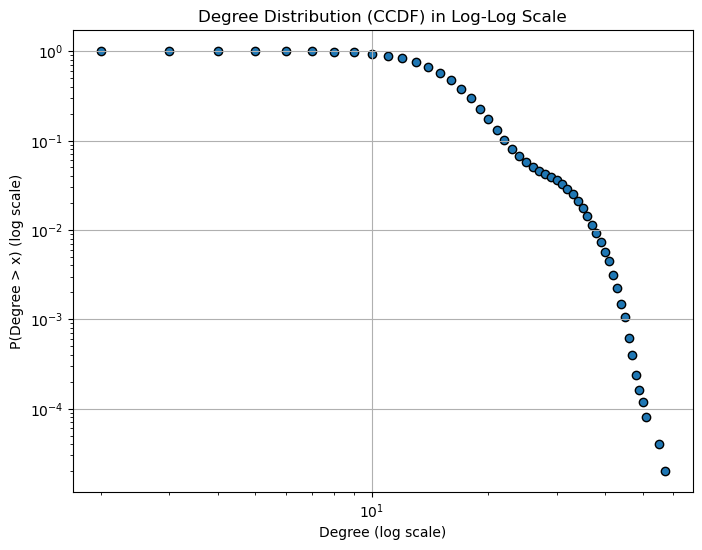

In [12]:
degrees = np.array(list(degree_count.values()))
degree_values, counts = np.unique(degrees, return_counts=True)
# Step 3: Calculate complementary cumulative distribution function (CCDF)
ccdf = np.cumsum(counts[::-1])[::-1] / N  # Probability of having degree > x

# Step 4: Plot scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(degree_values, ccdf, edgecolor='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Degree (log scale)")
plt.ylabel("P(Degree > x) (log scale)")
plt.title("Degree Distribution (CCDF) in Log-Log Scale")
plt.grid(True)
plt.show()

In [10]:
len(edge_list)

398592

In [ ]:
# Adjust edges according to the x, y conditions
final_edge_list = adjust_edges(edge_list, block_assignment, block_indices, N, X, Y)

# Print the results
print("Final Edge List (first 10 edges):\n", final_edge_list[:10])
print("Block Assignment:\n", {k: block_assignment[k] for k in list(block_assignment.keys())[:10]})

G = nx.MultiDiGraph()

# Add edges to the graph from the edge list
G.add_edges_from(final_edge_list)